In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import matplotlib.dates as mdates


plt.rcParams.update({
    'font.family'      : 'serif',
    'font.size'        : 9,
    'axes.titlesize'   : 10,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 9,
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'legend.fontsize'  : 8,
    'figure.dpi'       : 150,
})

# 1. Load Data

In [38]:
df = pd.read_csv('../../output/processed_data/04_Regression_handled.csv')

print('Shape    :', df.shape)
print('Day range:', df['day'].min(), 'to', df['day'].max())
print('\nSector names in data:')
print(df['sector'].value_counts().to_string())

Shape    : (63711, 18)
Day range: -298 to 91

Sector names in data:
sector
Food & Beverage               9831
Diversified Financials        9156
Consumer Services             8075
Capital Goods                 7375
Materials                     5033
Banks                         4112
Real Estate                   3885
Retailing                     3250
Insurance                     2756
Utilities                     2297
Consumer Durables             2045
Healthcare Equipment          2016
Commercial Services           1012
Energy                         767
Telecommunication Services     514
Transportation                 500
Household Products             317
Software & Services            257
Automobiles                    257
Food Retailing                 256


## 2. Filters

**Filter 1 — Thin trading:**  Remove stocks with trading days < 60 in estimate window

**Filter 2 — Extreme beta:**  Removed stocks with extreme beta values (outliers)

**Filter 3 — Micro-sectors:**  Removed sectors with stocks < 5

In [39]:
# ── Filter 1: Thin trading ────────────────────────────────────────────────────
est_window = df[(df['day'] >= -120) & (df['day'] <= -6)]

trading_days = (
    est_window.groupby('symbol')['day']
    .count()
    .reset_index()
    .rename(columns={'day': 'trading_days'})
)

sufficient    = trading_days[trading_days['trading_days'] >= 60]['symbol']
removed_thin  = trading_days[trading_days['trading_days'] <  60][['symbol', 'trading_days']]

print(f'Filter 1 — thin trading  : dropped {len(removed_thin)} stocks, kept {len(sufficient)}')
print('Removed stocks:')
print(removed_thin.sort_values('trading_days').to_string(index=False))

df = df[df['symbol'].isin(sufficient)].copy()

# ── Filter 2: Extreme beta ────────────────────────────────────────────────────
beta_per_stock = (
    df[(df['day'] >= -120) & (df['day'] <= -6)]
    .groupby('symbol')['beta']
    .first()
    .reset_index()
)

valid_beta    = beta_per_stock[
    (beta_per_stock['beta'] >= -3) &
    (beta_per_stock['beta'] <=  5)
]['symbol']
removed_beta  = beta_per_stock[
    (beta_per_stock['beta'] < -3) |
    (beta_per_stock['beta'] >  5)
][['symbol', 'beta']]

print(f'\nFilter 2 — extreme beta  : dropped {len(removed_beta)} stocks, kept {len(valid_beta)}')
print('Removed stocks:')
print(removed_beta.sort_values('beta', ascending=False).to_string(index=False))

df = df[df['symbol'].isin(valid_beta)].copy()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'\nTotal stocks before filters : {len(trading_days)}')
print(f'Removed — thin trading      : {len(removed_thin)}')
print(f'Removed — extreme beta      : {len(removed_beta)}')
print(f'Final qualifying stocks     : {len(valid_beta)}')

Filter 1 — thin trading  : dropped 3 stocks, kept 236
Removed stocks:
symbol  trading_days
   JFP             3
  MERC            21
  SWAD            29

Filter 2 — extreme beta  : dropped 15 stocks, kept 221
Removed stocks:
symbol       beta
  SHOT  36.418693
   LGL  27.338507
  SEYB  23.338283
   MAL  19.856236
   LPL  18.973150
   RHL  17.356327
   HNB  17.164575
   CDB  16.095632
  COCO  15.779955
  TKYO  11.799777
   VLL   9.423015
  COMB   9.351193
  AGST  -9.887605
   CHL -10.736335
   CIC -14.194072

Total stocks before filters : 239
Removed — thin trading      : 3
Removed — extreme beta      : 15
Final qualifying stocks     : 221


## 3. Compute Abnormal Return (AR)
`AR = R_i − (alpha + beta × R_m)`

In [40]:
df['AR'] = df['R_i'] - (df['alpha'] + df['beta'] * df['R_m'])

# Sanity check — mean AR in estimation window should be ≈ 0
mean_ar = df[(df['day'] >= -120) & (df['day'] <= -6)]['AR'].mean()
print(f'Mean AR in estimation window: {mean_ar:.6f}')

est_df   = df[(df['day'] >= -120) & (df['day'] <= -6)].copy()
event_df = df[(df['day'] >= -5)   & (df['day'] <= 30)].copy()

Mean AR in estimation window: 0.000000


## 4. Compute CAR per Stock over the Event Window

In [41]:
# ── CAR anchored at Day 0 ─────────────────────────────────────────────────────
# Post-event (day >= 0): cumsum forward from Day 0
# Pre-event  (day <  0): cumsum backwards to Day 0 (negated)

def compute_anchored_car(group):
    group = group.sort_values('day').copy()

    post = group[group['day'] >= 0].copy()
    post['CAR_anchored'] = post['AR'].cumsum()

    pre = group[group['day'] < 0].sort_values('day', ascending=False).copy()
    pre['CAR_anchored'] = -pre['AR'].cumsum()
    pre = pre.sort_values('day')

    return pd.concat([pre, post]).sort_values('day')

event_df = event_df.groupby('symbol', group_keys=False).apply(compute_anchored_car)
event_df['CAR_pct'] = event_df['CAR_anchored'] * 100

# Sanity check — Day 0 CAR should equal AR(Day 0) for every stock
day0 = event_df[event_df['day'] == 0]
match = (day0['CAR_anchored'].round(8) == day0['AR'].round(8)).all()
print(f'Day 0 sanity check passed: {match}')
print(f'Mean AR in event window  : {event_df["AR"].mean():.6f}')

Day 0 sanity check passed: False
Mean AR in event window  : -0.001963


C:\Users\USER\AppData\Local\Temp\ipykernel_44664\87639976.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  event_df = event_df.groupby('symbol', group_keys=False).apply(compute_anchored_car)


## 5. Aggregate Mean CAR by Sector and Day

In [42]:
sector_car = (
    event_df
    .groupby(['sector', 'day'])['CAR_pct']
    .mean()
    .reset_index()
    .rename(columns={'CAR_pct': 'mean_CAR_pct'})
)

print('Mean CAR on Day 0 by sector (cleaned):')
print(
    sector_car[sector_car['day'] == 0]
    .sort_values('mean_CAR_pct')
    .to_string(index=False)
)

Mean CAR on Day 0 by sector (cleaned):
                    sector  day  mean_CAR_pct
            Transportation    0     -1.230424
                 Utilities    0     -0.862065
                 Insurance    0     -0.701456
                 Materials    0     -0.528322
            Food Retailing    0     -0.417694
         Consumer Durables    0     -0.248946
    Diversified Financials    0     -0.242483
         Consumer Services    0     -0.216396
               Real Estate    0     -0.180114
        Household Products    0     -0.078565
                     Banks    0      0.034850
                    Energy    0      0.052259
       Software & Services    0      0.057278
             Capital Goods    0      0.118271
           Food & Beverage    0      0.150669
               Automobiles    0      0.164349
Telecommunication Services    0      0.360203
       Commercial Services    0      0.646687
      Healthcare Equipment    0      0.772047
                 Retailing    0      2.75

In [43]:
market_car = {}

windows = {
    'CAR(-5,-1)' : (-5, -1),
    'CAR(0,0)'   : ( 0,  0),
    'CAR(0,+5)'  : ( 0,  5),
    'CAR(-5,+30)': (-5, 30),
}


for label, (t1, t2) in windows.items():
    window_data = event_df[(event_df['day'] >= t1) & (event_df['day'] <= t2)]
    stock_car = window_data.groupby('symbol')['AR'].sum() * 100
    market_car[label] = {
        'mean'   : round(stock_car.mean(), 3),
        'std'    : round(stock_car.std(), 3),
        'n'      : len(stock_car)
    }

market_df = pd.DataFrame(market_car).T
print('Market-level CAR summary:')
print(market_df.to_string())

Market-level CAR summary:
              mean     std      n
CAR(-5,-1)  -0.983   3.936  221.0
CAR(0,0)     0.047   2.638  219.0
CAR(0,+5)   -1.817   5.733  221.0
CAR(-5,+30) -4.477  11.032  221.0


## Figure 0 — ASPI Index Trajectory
Daily ASPI close from Feb 2025 to Feb 2026 with landfall marker at Day 0.

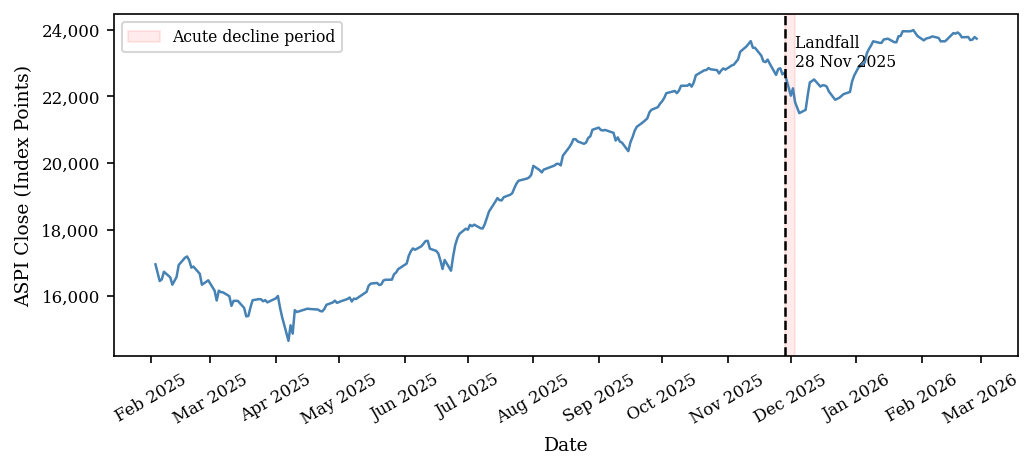

In [44]:
# ── ASPI trajectory: one row per trading date ────────────────────────────────
aspi_daily = (
    df[['date', 'day', 'aspi_close']]
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

# Identify Day 0 date (landfall)
landfall_date = aspi_daily.loc[aspi_daily['day'] == 0, 'date'].values
if len(landfall_date) == 0:
    landfall_date = aspi_daily.loc[(aspi_daily['day'] - 0).abs().idxmin(), 'date']
else:
    landfall_date = landfall_date[0]

aspi_daily['date_dt'] = pd.to_datetime(aspi_daily['date'])
landfall_dt = pd.to_datetime(landfall_date)

fig0, ax0 = plt.subplots(figsize=(7, 3.2))

ax0.plot(
    aspi_daily['date_dt'],
    aspi_daily['aspi_close'],
    color='steelblue',
    linewidth=1.2,
    zorder=2
)

ax0.axvline(
    x=landfall_dt,
    color='black',
    linewidth=1.2,
    linestyle='--',
    zorder=3
)
ax0.text(
    landfall_dt,
    aspi_daily['aspi_close'].max() * 0.995,
    '  Landfall\n  28 Nov 2025',
    fontsize=7.5,
    va='top',
    color='black'
)

trough_date = aspi_daily.loc[(aspi_daily['day'] - 5).abs().idxmin(), 'date_dt']
ax0.axvspan(
    landfall_dt, trough_date,
    alpha=0.08, color='red', zorder=1,
    label='Acute decline period'
)

ax0.set_xlabel('Date')
ax0.set_ylabel('ASPI Close (Index Points)')

ax0.xaxis.set_major_locator(mdates.MonthLocator())
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax0.tick_params(axis='x', rotation=30)

ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax0.legend(fontsize=7.5, loc='upper left')
plt.tight_layout()
fig0.savefig('../../output/figs/figure_aspi.pdf', bbox_inches='tight')
plt.show()


## Figure 1 — Sector CAR over the Event Window

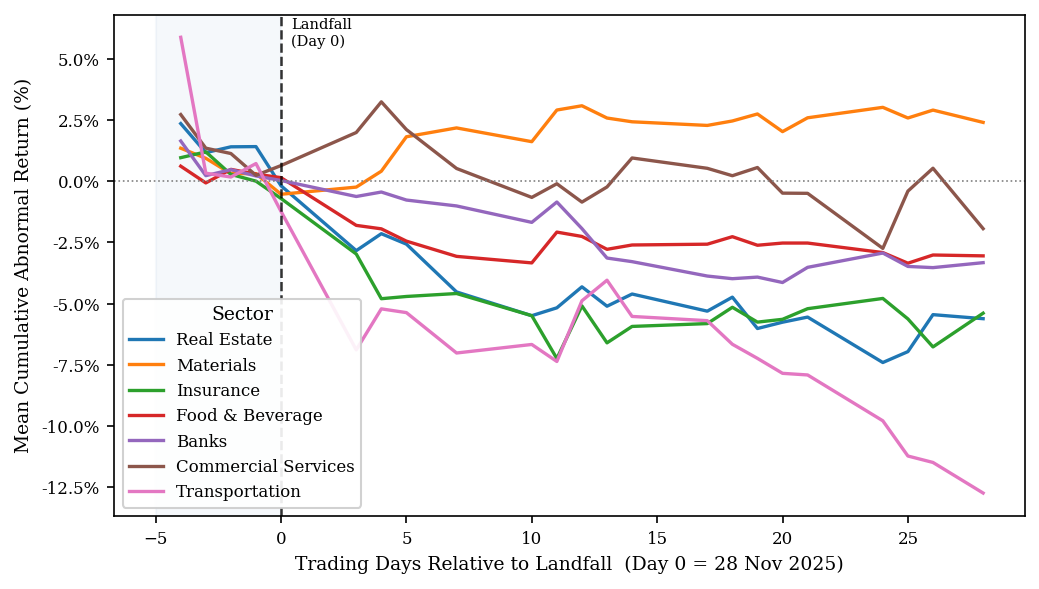

In [45]:
sectors = [
    'Real Estate',
    'Materials',
    'Insurance',
    'Food & Beverage',
    'Banks',
    'Commercial Services',
    'Transportation'
]

sector_car_plot = sector_car[sector_car['sector'].isin(sectors)].copy()
palette = sns.color_palette('tab10', n_colors=len(sectors))
col_map = dict(zip(sectors, palette))

fig1, ax1 = plt.subplots(figsize=(7, 4))

for sector in sectors:
    data = sector_car_plot[sector_car_plot['sector'] == sector].sort_values('day')
    ax1.plot(
        data['day'],
        data['mean_CAR_pct'],
        label=sector,
        color=col_map[sector],
        linewidth=1.6
    )

# Landfall marker
ax1.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.8)
ax1.text(0.4, ax1.get_ylim()[1] * 0.98,
         'Landfall\n(Day 0)', fontsize=7, color='black', va='top')

# Zero baseline
ax1.axhline(y=0, color='grey', linewidth=0.8, linestyle=':')

# Shade anticipation period
ax1.axvspan(-5, 0, alpha=0.05, color='steelblue')

ax1.set_xlabel('Trading Days Relative to Landfall  (Day 0 = 28 Nov 2025)')
ax1.set_ylabel('Mean Cumulative Abnormal Return (%)')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax1.legend(title='Sector', loc='lower left', framealpha=0.9)

plt.tight_layout()
fig1.savefig('../../output/figs/figure1_sector_CAR.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — Pre-Event Beta Distribution by Sector
Outliers beyond β ∈ [−3, 5] removed (thin-trading artefacts).

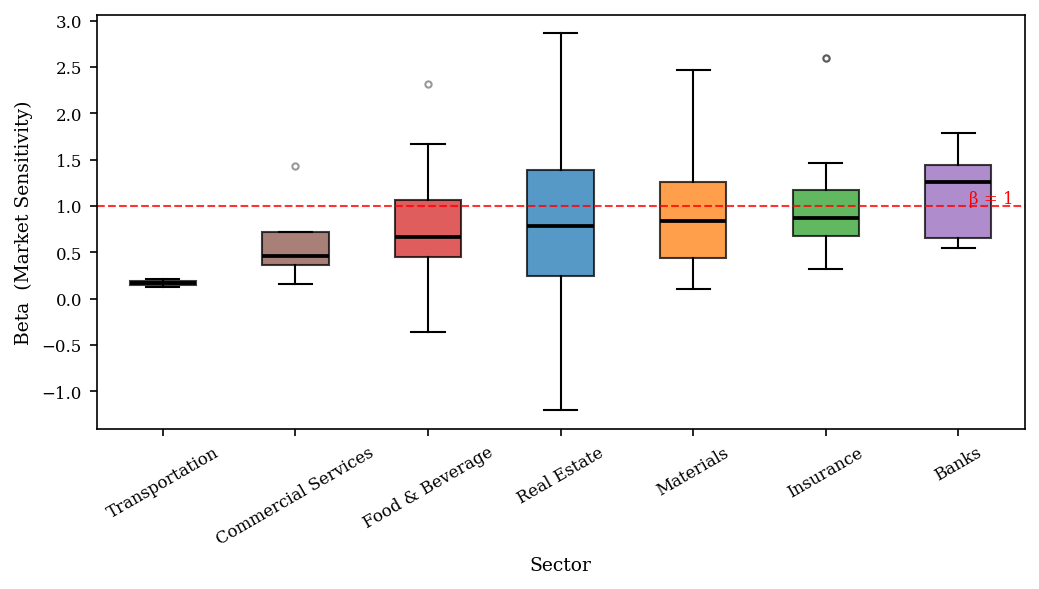

In [46]:
beta_per_stock = (
    est_df
    .groupby(['symbol', 'sector'])['beta']
    .first()
    .reset_index()
)

df_plot = beta_per_stock[beta_per_stock['sector'].isin(sectors)].copy()

# Sort by median beta low → high
sector_order = (
    df_plot.groupby('sector')['beta']
    .median()
    .sort_values()
    .index.tolist()
)

palette2 = [col_map[s] for s in sector_order]

fig2, ax2 = plt.subplots(figsize=(7, 4))

bp = ax2.boxplot(
    [df_plot[df_plot['sector'] == s]['beta'].values for s in sector_order],
    tick_labels=sector_order,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.4, linestyle='none'),
    whiskerprops=dict(linewidth=1),
    capprops=dict(linewidth=1),
)

for patch, colour in zip(bp['boxes'], palette2):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

ax2.axhline(y=1, color='red', linewidth=1, linestyle='--', alpha=0.8)
ax2.text(len(sector_order) + 0.08, 1.03, 'β = 1', fontsize=8, color='red')

ax2.set_xlabel('Sector')
ax2.set_ylabel('Beta  (Market Sensitivity)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
fig2.savefig('../../output/figs/figure2_beta_by_sector.pdf', bbox_inches='tight')
plt.show()

In [47]:
rows = []
for sector in sorted(event_df['sector'].unique()):
    sec_df = event_df[event_df['sector'] == sector]
    row = {'Sector': sector}
    for label, (t1, t2) in windows.items():
        window_data = sec_df[
            (sec_df['day'] >= t1) &
            (sec_df['day'] <= t2)
        ]
        stock_car = window_data.groupby('symbol')['AR'].sum() * 100
        row[label] = round(stock_car.mean(), 2)
    rows.append(row)

car_table = pd.DataFrame(rows).set_index('Sector')

print('CAR Summary Table (mean % per sector):')
print(car_table.to_string())

car_table.to_csv('../../output/tables/car_summary_table.csv')

CAR Summary Table (mean % per sector):
                            CAR(-5,-1)  CAR(0,0)  CAR(0,+5)  CAR(-5,+30)
Sector                                                                  
Automobiles                       1.42      0.16      -0.66         2.43
Banks                            -1.65      0.03      -0.76        -4.98
Capital Goods                    -1.70      0.12      -0.22        -2.97
Commercial Services              -2.73      0.65       2.12        -4.67
Consumer Durables                 0.24     -0.25       0.65        -2.28
Consumer Services                 0.92     -0.22      -3.87        -4.26
Diversified Financials           -1.16     -0.27      -2.38        -6.22
Energy                           -0.70      0.05      -0.69        -2.09
Food & Beverage                  -0.62      0.15      -2.45        -3.67
Food Retailing                   -1.50     -0.42       3.22        -4.66
Healthcare Equipment             -1.98      0.77       0.70        -2.43
Household Pr

In [48]:
df.to_csv('../../output/processed_data/05_filtered.csv', index=False)
print(f'✓ Saved 05_filtered.csv — {df["symbol"].nunique()} symbols, {len(df):,} rows')

✓ Saved 05_filtered.csv — 221 symbols, 56,165 rows
